# Parquet contra tablas de DuckDB

Las mismas siete consultas se ejecutan sobre los Parquet y sobre una tabla de DuckDB con los mismos datos, con tres cantidades de datos. Las mediciones salen de scripts/benchmark.py, que guarda sus resultados en docs/benchmark_tablas.csv y docs/benchmark_tiempos.csv.

In [1]:
import os
import platform
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

COLOR = {"yellow": "#eda100", "green": "#008300"}
NOMBRE = {"yellow": "Amarillo", "green": "Verde"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9, "figure.dpi": 110, "font.size": 10,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")

## Diseño del benchmark

Para consultar los Parquet (6.1), el script abre una conexión de DuckDB en memoria con las vistas de sql/vistas.sql, limitadas a los archivos de cada conjunto. Cada consulta lee los archivos.

Para la tabla (6.2), crea data/processed/benchmark_conjunto.duckdb y copia ahí la vista viajes con CREATE TABLE. Después la vista viajes pasa a leer esa tabla, así que viajes_validos y el texto de cada consulta son idénticos en las dos estrategias.

Las consultas (6.3) son un conteo, un filtro de un día, cuartiles exactos y cuatro consultas del ejercicio 4. En cada estrategia, cada consulta corre una vez y luego cinco veces más (6.4 y 6.5). Se guardan la primera ejecución y la mediana, el mínimo y el máximo de las otras cinco. Las dos estrategias se miden por separado para que no compitan por memoria, y el script compara que den el mismo resultado.

Las cantidades de datos (6.6) son 1 mes (enero de 2026), 8 meses (2026) y 20 meses (2024 y 2026).

Las mediciones se tomaron dentro del contenedor lab, con 32 hilos y 7.6 GB asignados por Docker Desktop en una laptop con Intel Core i9-13900HX. Los Parquet y las bases de DuckDB estaban en volúmenes de Docker, para que la lectura no pasara por el sistema de archivos de Windows.

In [2]:
print(f"DuckDB {duckdb.__version__}, Python {platform.python_version()}, {platform.system()}")
duckdb.sql("SELECT current_setting('threads') AS hilos, current_setting('memory_limit') AS memoria").df()

DuckDB 1.5.5, Python 3.11.14, Linux


,hilos,memoria
0,32,6.0 GiB


## 6.8 Consultas del benchmark

In [3]:
tiempos = pd.read_csv("docs/benchmark_tiempos.csv")
for consulta in tiempos.consulta.unique():
    print(f"-- sql/{consulta}")
    print(Path("sql", consulta).read_text(encoding="utf-8"))

-- sql/benchmark/01_conteo.sql
-- Registros por tipo de taxi
SELECT taxi, count(*) AS viajes
FROM viajes
GROUP BY taxi
ORDER BY taxi

-- sql/benchmark/02_un_dia.sql
-- Viajes y total promedio de un día, filtro que descarta casi todos los registros
SELECT taxi, count(*) AS viajes, round(avg(total_amount), 2) AS total_prom
FROM viajes
WHERE pickup_datetime >= TIMESTAMP '2026-01-15' AND pickup_datetime < TIMESTAMP '2026-01-16'
GROUP BY taxi
ORDER BY taxi

-- sql/benchmark/03_percentiles_total.sql
-- Cuartiles exactos del total por tipo de taxi
SELECT
    taxi,
    round(quantile_cont(total_amount, 0.25), 2) AS q1,
    round(quantile_cont(total_amount, 0.50), 2) AS mediana,
    round(quantile_cont(total_amount, 0.75), 2) AS q3
FROM viajes_validos
GROUP BY taxi
ORDER BY taxi

-- sql/ej4/01_viajes_por_mes.sql
-- Viajes válidos por mes y tipo de taxi
SELECT
    taxi,
    periodo,
    count(*) AS viajes,
    round(count(*) / day(last_day(periodo))) AS viajes_por_dia
FROM viajes_validos
GROUP B

| Consulta | Qué exige al motor |
| --- | --- |
| benchmark/01_conteo | Contar filas de todos los archivos |
| benchmark/02_un_dia | Filtrar un día, con casi todos los grupos de filas descartables |
| benchmark/03_percentiles_total | Cuartiles exactos, que ordenan todos los valores de una columna |
| ej4/01_viajes_por_mes | Reglas de calidad y agregación por mes |
| ej4/02_viajes_por_hora | Agregación por día y hora con una función de ventana |
| ej4/06_distritos | Unión con el catálogo de zonas |
| ej4/09_formas_de_pago | Agregaciones condicionales por forma de pago con una función de ventana |

## Tablas creadas

In [4]:
tablas = pd.read_csv("docs/benchmark_tablas.csv")
tablas

,conjunto,archivos,registros,mb_parquet,mb_duckdb,creacion_tabla_s
0,1 mes,2,3765161,65.2,106.4,1.00
1,8 meses,16,30040469,519.7,850.9,3.71
2,20 meses,40,71870407,1228.6,2021.7,8.66


La tabla ocupa 1.65 veces lo que ocupan los Parquet: 2,021.7 MB contra 1,228.6 MB con 20 meses. Crearla tomó 1.0 segundos con un mes, 3.7 con ocho meses y 8.7 con veinte, casi en proporción a los registros desde ocho meses.

## 6.7 Tiempos

Mediana de cinco ejecuciones, en segundos, y cuántas veces más rápida es la tabla.

In [5]:
orden = list(tablas.conjunto)
mediana = tiempos.pivot_table(index="consulta", columns=["conjunto", "estrategia"], values="mediana_s")
for conjunto in orden:
    mediana[(conjunto, "veces")] = (mediana[(conjunto, "parquet")] / mediana[(conjunto, "tabla")]).round(2)
mediana = mediana.reindex(columns=pd.MultiIndex.from_product([orden, ["parquet", "tabla", "veces"]]))
print("Mismo resultado en las dos estrategias:", tiempos.mismo_resultado.all())
mediana.round(3)

Mismo resultado en las dos estrategias: True


1 mes              8 meses              20 meses              
                                   parquet  tabla veces parquet  tabla veces  parquet  tabla  veces
consulta                                                                                           
benchmark/01_conteo.sql              0.004  0.003  1.21   0.008  0.008  0.99    0.018  0.018   0.97
benchmark/02_un_dia.sql              0.018  0.002  7.61   0.022  0.002  9.25    0.044  0.003  15.34
benchmark/03_percentiles_total.sql   0.434  0.319  1.36   2.648  2.564  1.03    6.560  6.597   0.99
ej4/01_viajes_por_mes.sql            0.115  0.030  3.83   0.258  0.189  1.37    0.585  0.446   1.31
ej4/02_viajes_por_hora.sql           0.142  0.076  1.87   0.300  0.415  0.72    0.763  1.043   0.73
ej4/06_distritos.sql                 0.156  0.036  4.35   0.310  0.219  1.42    0.764  0.462   1.65
ej4/09_formas_de_pago.sql            0.183  0.079  2.33   0.354  0.462  0.77    0.921  1.124   0.82

Rango entre la ejecución más rápida y la más lenta de cada consulta, para ver cuánto varían las mediciones.

In [6]:
rango = tiempos.assign(rango=tiempos.minimo_s.round(3).astype(str) + " a " + tiempos.maximo_s.round(3).astype(str))
rango.pivot_table(index="consulta", columns=["conjunto", "estrategia"], values="rango", aggfunc="first").reindex(columns=orden, level=0)

conjunto                                    1 mes                       8 meses                      20 meses               
estrategia                                parquet          tabla        parquet          tabla        parquet          tabla
consulta                                                                                                                    
benchmark/01_conteo.sql             0.003 a 0.004  0.003 a 0.003  0.008 a 0.009  0.008 a 0.008  0.017 a 0.019  0.018 a 0.018
benchmark/02_un_dia.sql             0.017 a 0.019  0.002 a 0.002  0.021 a 0.026  0.002 a 0.003   0.043 a 0.05  0.002 a 0.004
benchmark/03_percentiles_total.sql  0.405 a 0.492  0.297 a 0.339  2.472 a 2.788  2.358 a 2.589  6.285 a 7.052  6.012 a 6.895
ej4/01_viajes_por_mes.sql           0.114 a 0.117  0.028 a 0.034  0.253 a 0.271  0.182 a 0.206  0.581 a 0.602  0.442 a 0.466
ej4/02_viajes_por_hora.sql           0.14 a 0.151    0.07 a 0.08  0.286 a 0.306   0.413 a 0.43  0.732 a 0.795  0.995 a 1.122
ej4/06_distritos.sql                 0.155 a 0.16  0.034 a 0.036  0.302 a 0.325  0.207 a 0.238  0.751 a 0.786  0.456 a 0.464
ej4/09_formas_de_pago.sql           0.177 a 0.209   0.071 a 0.08  0.352 a 0.362  0.442 a 0.481  0.901 a 0.939  1.054 a 1.173

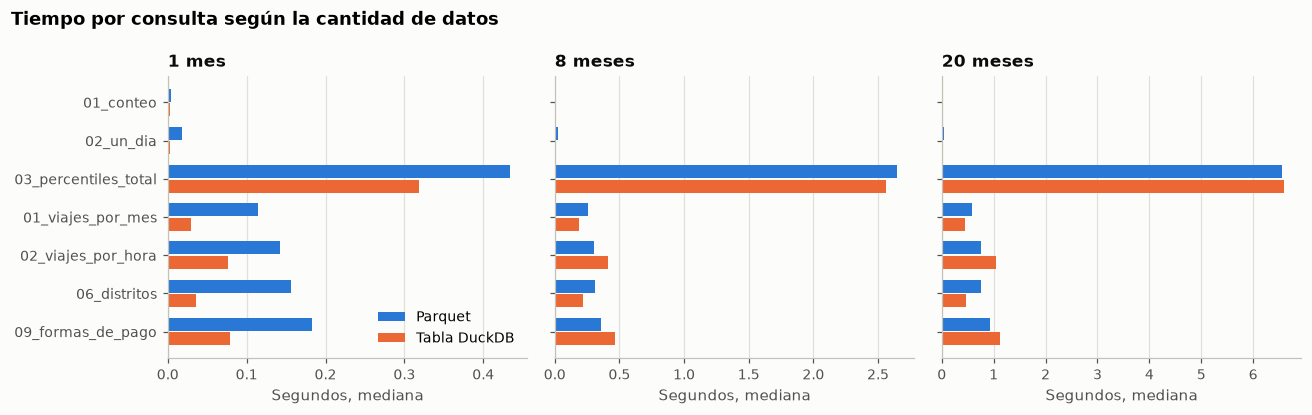

In [7]:
COLOR_ESTRATEGIA = {"parquet": "#2a78d6", "tabla": "#eb6834"}
NOMBRE_ESTRATEGIA = {"parquet": "Parquet", "tabla": "Tabla DuckDB"}
consultas = list(mediana.index)
y = np.arange(len(consultas))[::-1]
fig, ejes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for eje, conjunto in zip(ejes, orden):
    for i, estrategia in enumerate(["parquet", "tabla"]):
        eje.barh(y + (0.19 if i == 0 else -0.19), mediana[(conjunto, estrategia)], height=0.34,
                 color=COLOR_ESTRATEGIA[estrategia], label=NOMBRE_ESTRATEGIA[estrategia])
    eje.set_title(conjunto)
    eje.grid(axis="y", visible=False)
    eje.grid(axis="x", visible=True)
    eje.set_xlabel("Segundos, mediana")
ejes[0].set_yticks(y, [c.split("/")[1].removesuffix(".sql") for c in consultas])
ejes[0].legend(loc="lower right")
fig.suptitle("Tiempo por consulta según la cantidad de datos", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

Con un mes la tabla es más rápida en las siete consultas, de 1.2 a 7.6 veces. Con ocho y veinte meses la ventaja queda en tres consultas: el filtro de un día, que con veinte meses tarda 0.003 segundos en la tabla y 0.044 en los Parquet (15 veces), la unión con zonas (1.65 veces) y la agregación por mes (1.3 veces). El conteo y los cuartiles exactos tardan lo mismo en las dos estrategias, y las dos consultas con función de ventana, por hora y por forma de pago, tardan entre 22% y 38% más con la tabla.

Las mediciones varían poco: con veinte meses, la diferencia entre la ejecución más rápida y la más lenta de cada consulta no pasa del 15%.

## Planes de las consultas con ventana

Para entender por qué la tabla pierde en esas dos consultas se comparan sus planes con 20 meses. La consulta por mes sirve de referencia porque no usa ventana.

In [8]:
tabla = duckdb.connect("data/processed/benchmark_20_meses.duckdb", read_only=True)
parquet = duckdb.connect()
parquet.execute(Path("sql/vistas.sql").read_text(encoding="utf-8"))
planes = []
for consulta in ["ej4/01_viajes_por_mes.sql", "ej4/02_viajes_por_hora.sql", "ej4/09_formas_de_pago.sql"]:
    texto = Path("sql", consulta).read_text(encoding="utf-8")
    for estrategia, con in [("parquet", parquet), ("tabla", tabla)]:
        plan = con.execute("EXPLAIN " + texto).fetchall()[0][1]
        # Cada lectura de Parquet aparece cuatro veces en el plan, dos por tipo de taxi
        lecturas = plan.count("SEQ_SCAN") if estrategia == "tabla" else plan.count("READ_PARQUET") // 4
        planes.append({"consulta": consulta, "estrategia": estrategia, "lecturas_de_los_viajes": lecturas,
                       "operador_window": "WINDOW" in plan, "union_hash": "HASH_JOIN" in plan})
tabla.close()
pd.DataFrame(planes)

,consulta,estrategia,lecturas_de_los_viajes,operador_window,union_hash
0,ej4/01_viajes_por_mes.sql,parquet,1,False,False
1,ej4/01_viajes_por_mes.sql,tabla,1,False,False
2,ej4/02_viajes_por_hora.sql,parquet,1,True,False
3,ej4/02_viajes_por_hora.sql,tabla,2,False,True
4,ej4/09_formas_de_pago.sql,parquet,1,True,False
5,ej4/09_formas_de_pago.sql,tabla,2,False,True


Con la tabla, el optimizador cambia la función de ventana por una segunda agregación que después une al resultado, y para eso recorre los 72 millones de filas dos veces. Con los Parquet conserva el operador de ventana y recorre los datos una vez. La tabla lee más rápido, pero en esas consultas hace el doble de trabajo. Materializar los datos no garantiza un plan mejor, porque el optimizador decide distinto con las estadísticas de cada fuente.

In [9]:
totales = tiempos.groupby(["conjunto", "estrategia"]).mediana_s.sum().unstack().reindex(orden)
totales["creacion_tabla_s"] = tablas.set_index("conjunto").creacion_tabla_s
totales["ahorro_por_ronda_s"] = totales.parquet - totales.tabla
# Sin ahorro por ronda la creación de la tabla no se recupera
totales["rondas_para_recuperar"] = (totales.creacion_tabla_s / totales.ahorro_por_ronda_s).where(totales.ahorro_por_ronda_s > 0).round(1)
totales.round(3)

estrategia,parquet,tabla,creacion_tabla_s,ahorro_por_ronda_s,rondas_para_recuperar
conjunto,,,,,
1 mes,1.052,0.544,1.00,0.507,2.0
8 meses,3.901,3.859,3.71,0.042,88.8
20 meses,9.654,9.694,8.66,-0.039,NaN


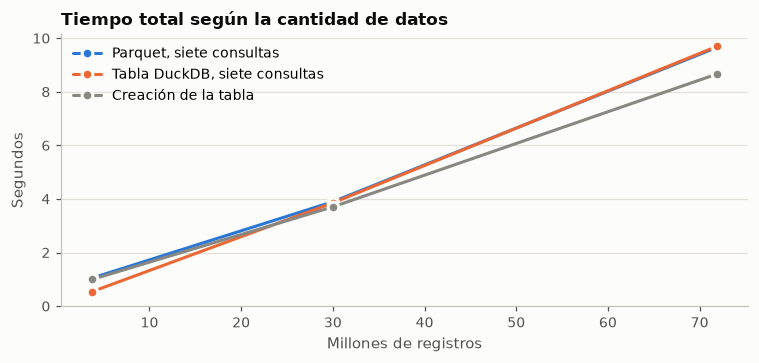

In [10]:
fig, eje = plt.subplots(figsize=(7, 3.4))
registros = tablas.set_index("conjunto").registros.reindex(orden) / 1e6
for estrategia in ["parquet", "tabla"]:
    eje.plot(registros, totales[estrategia], color=COLOR_ESTRATEGIA[estrategia], marker="o", markersize=7,
             markeredgecolor="#fcfcfb", markeredgewidth=2, label=f"{NOMBRE_ESTRATEGIA[estrategia]}, siete consultas")
eje.plot(registros, totales.creacion_tabla_s, color="#898781", marker="o", markersize=7,
         markeredgecolor="#fcfcfb", markeredgewidth=2, label="Creación de la tabla")
eje.set_xlabel("Millones de registros")
eje.set_ylabel("Segundos")
eje.set_ylim(bottom=0)
eje.legend(loc="upper left")
eje.set_title("Tiempo total según la cantidad de datos")
fig.tight_layout()

Sumadas, las siete consultas tardan 1.05 segundos sobre los Parquet y 0.54 sobre la tabla con un mes, así que la tabla recupera su creación en dos rondas. Con ocho meses tardan 3.90 contra 3.86 segundos y con veinte, 9.65 contra 9.69. Ahí las ganancias de la tabla en filtros, uniones y agregaciones simples se compensan con lo que pierde en las consultas con ventana: con ocho meses necesita 89 rondas para recuperar su creación y con veinte no la recupera.

## 6.9 Análisis

La diferencia entre estrategias depende de qué parte del trabajo domina cada consulta. Leer los Parquet tiene un costo fijo por consulta: abrir cada archivo, leer su pie, unir esquemas con union_by_name y calcular el periodo desde el nombre del archivo. Con un mes ese costo pesa más que el cálculo, y la tabla, con los datos en el formato de DuckDB y el periodo ya calculado, gana en todo.

Con más datos el cálculo pasa a dominar. Ordenar 72 millones de totales para los cuartiles exactos cuesta lo mismo sin importar de dónde vienen los datos, y lo mismo pasa al contar filas, porque los Parquet guardan el conteo en su pie. En las consultas con ventana la tabla pierde por el plan que elige el optimizador.

La tabla mantiene la ventaja en filtros selectivos y uniones. Guarda el mínimo y el máximo de cada bloque de filas, así que para un día descarta casi todo sin leerlo, mientras la lectura de Parquet abre 40 archivos aunque después salte sus grupos de filas. En la unión con zonas gana porque el catálogo ya está en la base y no se lee un CSV en cada consulta.

A cambio, la tabla ocupa 65% más espacio que los Parquet, tarda en crearse y queda desactualizada cuando llega un mes nuevo, porque hay que volver a crearla o insertarle los archivos.

## 6.10 Cuándo usar cada estrategia

Consultar los Parquet sin cargarlos conviene en la exploración inicial, en consultas que se ejecutan una o pocas veces, cuando llegan archivos nuevos con frecuencia, cuando el costo está en el cálculo y no en la lectura, y cuando no se quiere duplicar el almacenamiento ni perder un formato que otras herramientas leen.

Materializar una tabla conviene cuando las mismas consultas se repiten muchas veces, como en un tablero o en reportes diarios, cuando hay filtros selectivos o uniones frecuentes, cuando conviene guardar columnas calculadas como el periodo, y cuando los Parquet están en un almacenamiento lento o remoto. Con los tiempos medidos, una tabla de 20 meses no se paga con esta mezcla de consultas, pero sí con consultas que filtran pocos registros o unen otras tablas, y sus planes deben revisarse con EXPLAIN porque no siempre son mejores. Un tablero puede ir más lejos y materializar los resultados que muestra en lugar de los viajes, como hace el ejercicio 7.